# Investigation: Plasma -> Epithelial, Plasma rule (Multi-Stage Evaluation)

This notebook investigates the association rule **Plasma -> Epithelial, Plasma** across different disease stages (Control, Mild, Severe). It calculates per-FOV metrics to directly compare standard FP-Growth (binary) vs Weighted FP-Growth (distance-decay) pass rates.

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Add root to path for constants and utils
sys.path.append(os.path.abspath('../../'))
import constants
from utils.rules import build_cell_item_token, passes_rule_support_policy, _extract_base_lineage

RADIUS = constants.CONFIG['RADIUS']
BANDWIDTH = constants.CONFIG.get('BANDWIDTH', RADIUS)
MIN_SUPPORT = constants.CONFIG['MIN_SUPPORT']
MIN_ABS_SUPPORT = constants.CONFIG.get('MIN_ABS_SUPPORT', 5)
MIN_CONFIDENCE = constants.CONFIG['MIN_CONFIDENCE']
MIN_LIFT = constants.CONFIG['MIN_LIFT']
SCORE_COLUMN = 'Pathological score'  # change to 'Clinical score' if needed

ANTECEDENT_BASE = 'Plasma'
ANTECEDENT_REQUIRED_MARKERS = ()
CONSEQUENT_BASE = 'Epithelial'
CONSEQUENT_REQUIRED_MARKERS = ()


## Step 1: Data Loading & Functional Subtypes

Load the cell and metadata tables, identify disease stages, and append the `functional_subtypes` array to every cell.

In [2]:
def _add_functional_subtypes(df):
    if not constants.USE_FUNCTIONAL_MARKERS:
        df["functional_subtypes"] = [[] for _ in range(len(df))]
        return df
    functional_subtypes_list = [[] for _ in range(len(df))]
    idx_to_pos = {idx: i for i, idx in enumerate(df.index)}
    for base_type, markers in constants.CELLTYPE_MARKER_THRESHOLDS.items():
        type_mask = df["cell type"] == base_type
        for marker, threshold in markers.items():
            if marker in df.columns:
                mask = type_mask & (df[marker] > threshold)
                subtype_label = f"{base_type}_{marker}+"
                matching_indices = df.index[mask]
                for idx in matching_indices:
                    functional_subtypes_list[idx_to_pos[idx]].append(subtype_label)
    df["functional_subtypes"] = functional_subtypes_list
    return df

cell_table_path = '../../data/MIBIGutCsv/cell_table.csv'
fov_meta_path = '../../data/MIBIGutCsv/fovs_metadata.csv'
biopsy_meta_path = '../../data/MIBIGutCsv/biopsy_metadata.csv'

df_cells = pd.read_csv(cell_table_path)
df_fovs = pd.read_csv(fov_meta_path)
df_biopsy = pd.read_csv(biopsy_meta_path)

# Merge FOV with Biopsy to get score columns and Localization
df_fovs = pd.merge(
    df_fovs,
    df_biopsy[['Biopsy_ID', 'Pathological score', 'Clinical score', 'Localization']],
    left_on='Patient',
    right_on='Biopsy_ID',
    how='left'
)

# --- Standardized Organ Enrichment (from investigation_01_colon.ipynb) ---
def get_organ(row):
    if pd.notna(row.get("Localization")): return row["Localization"]
    cohort = str(row.get("Cohort", ""))
    if "Colon" in cohort: return "Colon"
    if "Duodenum" in cohort: return "Duodenum"
    return "Unknown"

df_fovs["Organ"] = df_fovs.apply(get_organ, axis=1)
# -------------------------------------------------------------------------

# Define FOV lists for each cohort, explicitly split by Stage and Organ
control_cohorts = ['Duodenum_Cohort_Control_1', 'Duodenum_Cohort_Control_2', 'Colon_Cohort_Control']

# Colon
colon_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_mild_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Mild') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_severe_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Severe') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()

# Duodenum
duodenum_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_mild_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Mild') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_severe_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Severe') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()

# Normalize Coordinates
fov_to_size = df_fovs.set_index('FOV')['Size [um]'].to_dict()
def normalize_coords(row):
    size = fov_to_size.get(row['fov'], 800)
    res = 1024 if size == 400 else 2048
    return row['centroid_x'] * (size / res), row['centroid_y'] * (size / res)

df_cells[['x_um', 'y_um']] = df_cells.apply(lambda row: pd.Series(normalize_coords(row)), axis=1)

# Add Functional Subtypes
df_cells = _add_functional_subtypes(df_cells)

print(f"Total Cells: {len(df_cells)}")
print(f"Colon Control FOVs: {len(colon_control_fovs)}")
print(f"Colon Mild FOVs: {len(colon_mild_fovs)}")
print(f"Colon Severe FOVs: {len(colon_severe_fovs)}")
print(f"Duodenum Control FOVs: {len(duodenum_control_fovs)}")
print(f"Duodenum Mild FOVs: {len(duodenum_mild_fovs)}")
print(f"Duodenum Severe FOVs: {len(duodenum_severe_fovs)}")
print(f"Stage column used: {SCORE_COLUMN}")



Total Cells: 713372
Colon Control FOVs: 25
Colon Mild FOVs: 40
Colon Severe FOVs: 32
Duodenum Control FOVs: 52
Duodenum Mild FOVs: 103
Duodenum Severe FOVs: 36
Stage column used: Pathological score


## Step 2: Evaluation Framework

Define a reusable function that iterates over a given list of FOVs, computes both binary and weighted metrics *per FOV*, and verifies how many FOVs pass the algorithm thresholds. Finally, it visualizes the FOV with the highest target cell density.

In [3]:
def evaluate_cohort(cohort_name, fov_list, df_cells_all):
    print(f"==============================================")
    print(f"Evaluating Cohort: {cohort_name}")
    print(f"==============================================\n")

    binary_pass_count = 0
    weighted_pass_count = 0
    valid_fovs = 0

    global_binary_transactions = []
    global_weighted_transactions = []
    passing_binary_transactions = []
    passing_weighted_transactions = []

    max_target_count = -1
    max_target_fov = None

    def _parse_token(token, suffix):
        token = str(token)
        tail = f"_{suffix}"
        if not token.endswith(tail):
            return None, set()
        core = token[:-len(tail)]
        base = _extract_base_lineage(core)
        markers = {part for part in core.split('_') if part.endswith('+')}
        return base, markers

    def _matches_rule_item(token, base, suffix, required_markers=()):
        token_base, token_markers = _parse_token(token, suffix)
        if token_base != base:
            return False
        return set(required_markers).issubset(token_markers)

    def _has_item(binary_trans, base, suffix, required_markers=()):
        return any(_matches_rule_item(item, base, suffix, required_markers) for item in binary_trans)

    def _weight_for_item(weighted_trans, base, suffix, required_markers=()):
        return min(
            sum(float(v) for k, v in weighted_trans.items() if _matches_rule_item(k, base, suffix, required_markers)),
            1.0,
        )

    def _rule_item_label(base, required_markers):
        if not required_markers:
            return base
        return f"{base}_{'_'.join(required_markers)}"

    for fov in fov_list:
        fov_data = df_cells_all[df_cells_all['fov'] == fov]
        if fov_data.empty:
            continue
        valid_fovs += 1

        coords = fov_data[['x_um', 'y_um']].values
        types = fov_data['cell type'].values
        subtypes = fov_data['functional_subtypes'].values

        target_count = sum(
            1
            for t, st in zip(types, subtypes)
            if _matches_rule_item(
                build_cell_item_token(t, st, suffix='CENTER'),
                ANTECEDENT_BASE,
                'CENTER',
                ANTECEDENT_REQUIRED_MARKERS,
            )
        )
        if target_count > max_target_count:
            max_target_count = target_count
            max_target_fov = fov

        nn = NearestNeighbors(radius=RADIUS).fit(coords)
        distances, neighbors_idx = nn.radius_neighbors(coords, return_distance=True)

        fov_binary_trans = []
        fov_weighted_trans = []

        for i, (idxs, dists) in enumerate(zip(neighbors_idx, distances)):
            if len(idxs) < constants.CONFIG.get("MIN_CELLS_PER_PATCH", 2):
                continue

            center_token = build_cell_item_token(types[i], subtypes[i], suffix='CENTER')

            b_trans = {center_token}
            w_trans = {center_token: 1.0}

            for n_idx, d in zip(idxs, dists):
                if n_idx == i:
                    continue

                neighbor_token = build_cell_item_token(types[n_idx], subtypes[n_idx], suffix='NEIGHBOR')
                b_trans.add(neighbor_token)

                w = np.exp(-0.5 * (d / BANDWIDTH) ** 2)
                w_trans[neighbor_token] = w_trans.get(neighbor_token, 0.0) + w

            w_trans = {k: min(v, 1.0) for k, v in w_trans.items()}

            fov_binary_trans.append(b_trans)
            fov_weighted_trans.append(w_trans)
            global_binary_transactions.append(b_trans)
            global_weighted_transactions.append(w_trans)

        n_trans = len(fov_binary_trans)
        if n_trans == 0:
            print(f"FOV: {fov} | 0 Transactions")
            continue

        b_sup_ant = sum(
            1 for t in fov_binary_trans
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        ) / n_trans
        b_sup_con = sum(
            1 for t in fov_binary_trans
            if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / n_trans
        b_sup_joint = sum(
            1 for t in fov_binary_trans
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / n_trans
        b_conf = b_sup_joint / b_sup_ant if b_sup_ant > 0 else 0
        b_lift = b_conf / b_sup_con if b_sup_con > 0 else 0

        b_pass = False
        if b_sup_joint >= MIN_SUPPORT and b_conf >= MIN_CONFIDENCE and b_lift >= MIN_LIFT:
            binary_pass_count += 1
            b_pass = True

        w_sup_ant = sum(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            for t in fov_weighted_trans
        ) / n_trans
        w_sup_con = sum(
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
            for t in fov_weighted_trans
        ) / n_trans
        w_sup_joint = sum(
            min(
                _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
                _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
            )
            for t in fov_weighted_trans
        ) / n_trans
        w_conf = w_sup_joint / w_sup_ant if w_sup_ant > 0 else 0
        w_lift = w_conf / w_sup_con if w_sup_con > 0 else 0

        w_pass = False
        if (
            passes_rule_support_policy(constants.CONFIG, w_sup_joint, w_conf, w_lift, num_transactions=n_trans)
            and w_conf >= MIN_CONFIDENCE
            and w_lift >= MIN_LIFT
        ):
            weighted_pass_count += 1
            w_pass = True

        if b_pass:
            passing_binary_transactions.extend(fov_binary_trans)
        if w_pass:
            passing_weighted_transactions.extend(fov_weighted_trans)

        print(f"FOV: {fov} | Transactions: {n_trans}")
        print(f"  [Binary]   Sup: {b_sup_joint:.4f} | Conf: {b_conf:.4f} | Lift: {b_lift:.4f} | PASS: {b_pass}")
        print(f"  [Weighted] Sup: {w_sup_joint:.4f} | Conf: {w_conf:.4f} | Lift: {w_lift:.4f} | PASS: {w_pass}\n")

    ant_label = _rule_item_label(ANTECEDENT_BASE, ANTECEDENT_REQUIRED_MARKERS)
    con_label = _rule_item_label(CONSEQUENT_BASE, CONSEQUENT_REQUIRED_MARKERS)
    print(f"\n[Algorithm Comparison: {ant_label}_CENTER -> {con_label}_NEIGHBOR (rule-aware)]")
    print(f"FOVs passing standard FP-Growth (Binary): {binary_pass_count} / {valid_fovs}")
    print(f"FOVs passing Weighted FP-Growth (Distance-decay): {weighted_pass_count} / {valid_fovs}")

    if not global_binary_transactions:
        return

    g_n_trans = len(global_binary_transactions)
    gb_sup_ant = sum(
        1 for t in global_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_sup_con = sum(
        1 for t in global_binary_transactions
        if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_sup_joint = sum(
        1 for t in global_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_conf = gb_sup_joint / gb_sup_ant if gb_sup_ant > 0 else 0
    gb_lift = gb_conf / gb_sup_con if gb_sup_con > 0 else 0

    gw_sup_ant = sum(
        _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_sup_con = sum(
        _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_sup_joint = sum(
        min(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
        )
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_conf = gw_sup_joint / gw_sup_ant if gw_sup_ant > 0 else 0
    gw_lift = gw_conf / gw_sup_con if gw_sup_con > 0 else 0

    if passing_binary_transactions:
        p_n_trans = len(passing_binary_transactions)
        pb_sup_ant = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_sup_con = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_sup_joint = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_conf = pb_sup_joint / pb_sup_ant if pb_sup_ant > 0 else 0
        pb_lift = pb_conf / pb_sup_con if pb_sup_con > 0 else 0

        pw_sup_ant = sum(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_sup_con = sum(
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_sup_joint = sum(
            min(
                _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
                _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
            )
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_conf = pw_sup_joint / pw_sup_ant if pw_sup_ant > 0 else 0
        pw_lift = pw_conf / pw_sup_con if pw_sup_con > 0 else 0
    else:
        pb_sup_joint = pb_conf = pb_lift = 0
        pw_sup_joint = pw_conf = pw_lift = 0

    print(f"\n[Aggregate Metrics: ALL FOVs]")
    print(f"          {'Binary':>12} | {'Weighted':>12}")
    print(f"Approved: {binary_pass_count:>12} | {weighted_pass_count:>12}  (out of {valid_fovs} valid FOVs)")
    print(f"Support : {gb_sup_joint:>12.4f} | {gw_sup_joint:>12.4f}")
    print(f"Conf    : {gb_conf:>12.4f} | {gw_conf:>12.4f}")
    print(f"Lift    : {gb_lift:>12.4f} | {gw_lift:>12.4f}")

    print(f"\n[Aggregate Metrics: ONLY PASSING FOVs]")
    print(f"          {'Binary':>12} | {'Weighted':>12}")
    print(f"Support : {pb_sup_joint:>12.4f} | {pw_sup_joint:>12.4f}")
    print(f"Conf    : {pb_conf:>12.4f} | {pw_conf:>12.4f}")
    print(f"Lift    : {pb_lift:>12.4f} | {pw_lift:>12.4f}")

    if max_target_fov:
        print(f"\nVisualizing Representative FOV: {max_target_fov} ({max_target_count} matching antecedent cells)")
        _plot_fov(max_target_fov, df_cells_all)

def _plot_fov(fov, df_cells_all):
    fov_df = df_cells_all[df_cells_all['fov'] == fov].copy()

    def get_plot_class(row):
        if row['cell type'] == 'Plasma': return 'Plasma'
        elif row['cell type'] == 'Epithelial': return 'Epithelial'
        return 'Other'
        
    fov_df['PlotClass'] = fov_df.apply(get_plot_class, axis=1)
    
    plt.figure(figsize=(10, 10))
    others = fov_df[fov_df['PlotClass'] == 'Other']
    sns.scatterplot(data=others, x='x_um', y='y_um', color='lightgrey', alpha=0.3, s=20)
    epi = fov_df[fov_df['PlotClass'] == 'Epithelial']
    sns.scatterplot(data=epi, x='x_um', y='y_um', color='blue', alpha=0.5, s=30, label='Epithelial')
    target = fov_df[fov_df['PlotClass'] == 'Plasma']
    sns.scatterplot(data=target, x='x_um', y='y_um', color='red', s=40, edgecolor='black', zorder=10, label='Plasma')

    plt.title(f"Spatial Distribution in FOV {fov}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.show()


## Step 3: Run Evaluation on Control Cohort

Evaluating Cohort: Colon - Control

FOV: Control_Colon_01_FOV_1 | Transactions: 1401
  [Binary]   Sup: 0.1078 | Conf: 0.8343 | Lift: 0.9964 | PASS: False
  [Weighted] Sup: 0.1016 | Conf: 0.7863 | Lift: 0.9860 | PASS: False

FOV: Control_Colon_01_FOV_2 | Transactions: 1778
  [Binary]   Sup: 0.0737 | Conf: 0.8618 | Lift: 0.9873 | PASS: False
  [Weighted] Sup: 0.0711 | Conf: 0.8313 | Lift: 0.9687 | PASS: False

FOV: Control_Colon_01_FOV_3 | Transactions: 1624
  [Binary]   Sup: 0.0616 | Conf: 0.6757 | Lift: 0.8332 | PASS: False
  [Weighted] Sup: 0.0568 | Conf: 0.6232 | Lift: 0.8006 | PASS: False

FOV: Control_Colon_01_FOV_4 | Transactions: 2046
  [Binary]   Sup: 0.0391 | Conf: 0.7547 | Lift: 1.5442 | PASS: True
  [Weighted] Sup: 0.0379 | Conf: 0.7312 | Lift: 1.5332 | PASS: True

FOV: Control_Colon_01_FOV_5 | Transactions: 1877
  [Binary]   Sup: 0.2680 | Conf: 0.9162 | Lift: 0.9975 | PASS: False
  [Weighted] Sup: 0.2582 | Conf: 0.8827 | Lift: 0.9943 | PASS: False

FOV: Control_Colon_01_FOV_

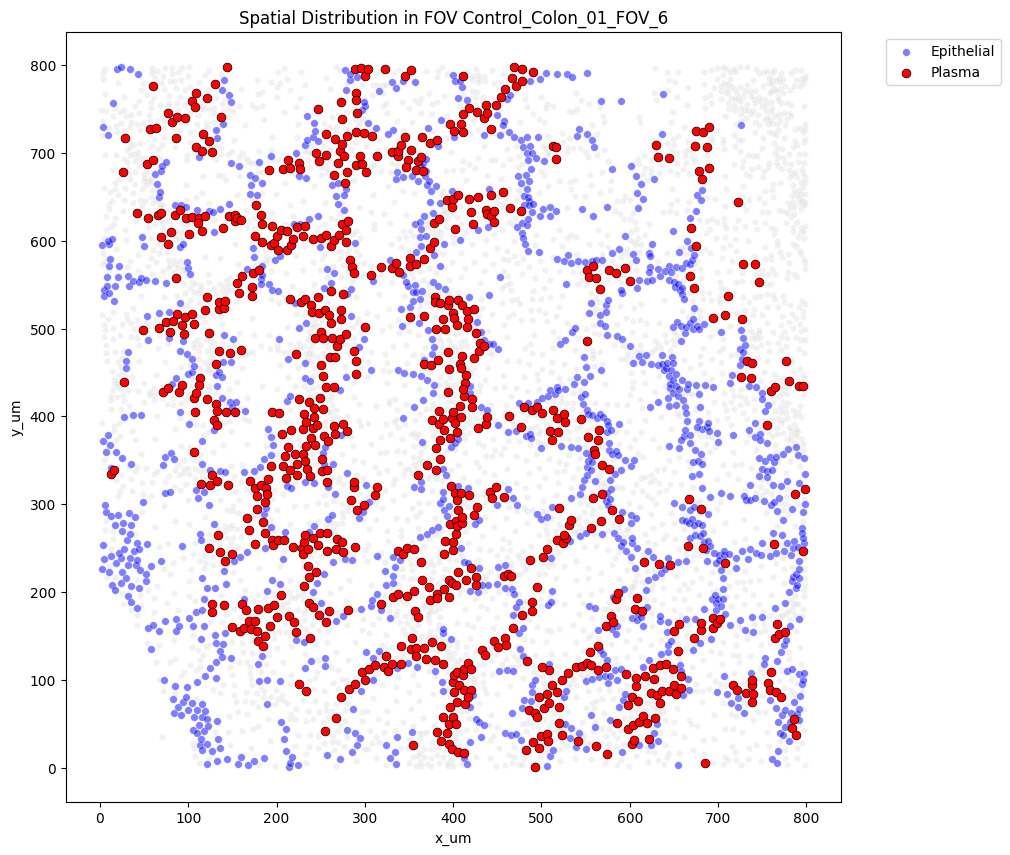

In [4]:
evaluate_cohort("Colon - Control", colon_control_fovs, df_cells)


Evaluating Cohort: Colon - Mild

FOV: GVHD_13_FOV_1 | Transactions: 1462
  [Binary]   Sup: 0.0157 | Conf: 1.0000 | Lift: 1.0951 | PASS: False
  [Weighted] Sup: 0.0154 | Conf: 0.9766 | Lift: 1.0866 | PASS: False

FOV: GVHD_13_FOV_2 | Transactions: 1661
  [Binary]   Sup: 0.0193 | Conf: 0.9697 | Lift: 1.0358 | PASS: False
  [Weighted] Sup: 0.0188 | Conf: 0.9464 | Lift: 1.0236 | PASS: False

FOV: GVHD_13_FOV_3 | Transactions: 1294
  [Binary]   Sup: 0.0015 | Conf: 1.0000 | Lift: 1.1041 | PASS: False
  [Weighted] Sup: 0.0015 | Conf: 1.0000 | Lift: 1.1214 | PASS: False

FOV: GVHD_17_FOV_1 | Transactions: 1503
  [Binary]   Sup: 0.0067 | Conf: 0.9091 | Lift: 1.1463 | PASS: False
  [Weighted] Sup: 0.0067 | Conf: 0.9091 | Lift: 1.1767 | PASS: False

FOV: GVHD_17_FOV_2 | Transactions: 1188
  [Binary]   Sup: 0.0093 | Conf: 0.8462 | Lift: 1.3004 | PASS: False
  [Weighted] Sup: 0.0083 | Conf: 0.7571 | Lift: 1.2160 | PASS: False

FOV: GVHD_17_FOV_3 | Transactions: 1492
  [Binary]   Sup: 0.0060 | Conf:

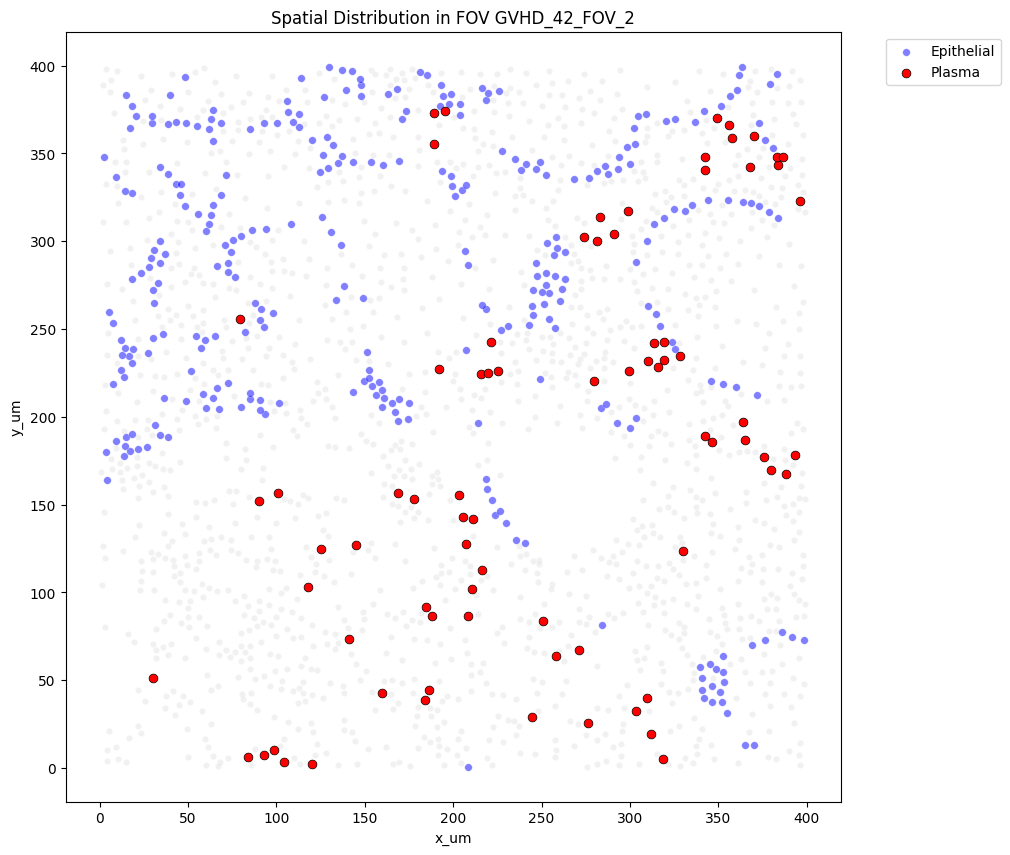

In [5]:
evaluate_cohort("Colon - Mild", colon_mild_fovs, df_cells)


Evaluating Cohort: Colon - Severe

FOV: GVHD_01_FOV_1 | Transactions: 1801
  [Binary]   Sup: 0.0155 | Conf: 0.7778 | Lift: 0.8711 | PASS: False
  [Weighted] Sup: 0.0152 | Conf: 0.7598 | Lift: 0.8616 | PASS: False

FOV: GVHD_01_FOV_2_R | Transactions: 2040
  [Binary]   Sup: 0.0196 | Conf: 0.4167 | Lift: 0.6615 | PASS: False
  [Weighted] Sup: 0.0180 | Conf: 0.3834 | Lift: 0.6295 | PASS: False

FOV: GVHD_01_FOV_3_R | Transactions: 1852
  [Binary]   Sup: 0.0119 | Conf: 0.5366 | Lift: 0.7013 | PASS: False
  [Weighted] Sup: 0.0114 | Conf: 0.5141 | Lift: 0.6898 | PASS: False

FOV: GVHD_01_FOV_4 | Transactions: 1937
  [Binary]   Sup: 0.0325 | Conf: 0.8873 | Lift: 0.9191 | PASS: False
  [Weighted] Sup: 0.0313 | Conf: 0.8532 | Lift: 0.8941 | PASS: False

FOV: GVHD_01_FOV_5 | Transactions: 2103
  [Binary]   Sup: 0.0048 | Conf: 0.3704 | Lift: 0.4631 | PASS: False
  [Weighted] Sup: 0.0042 | Conf: 0.3293 | Lift: 0.4180 | PASS: False

FOV: GVHD_01_FOV_6_R | Transactions: 2010
  [Binary]   Sup: 0.0662

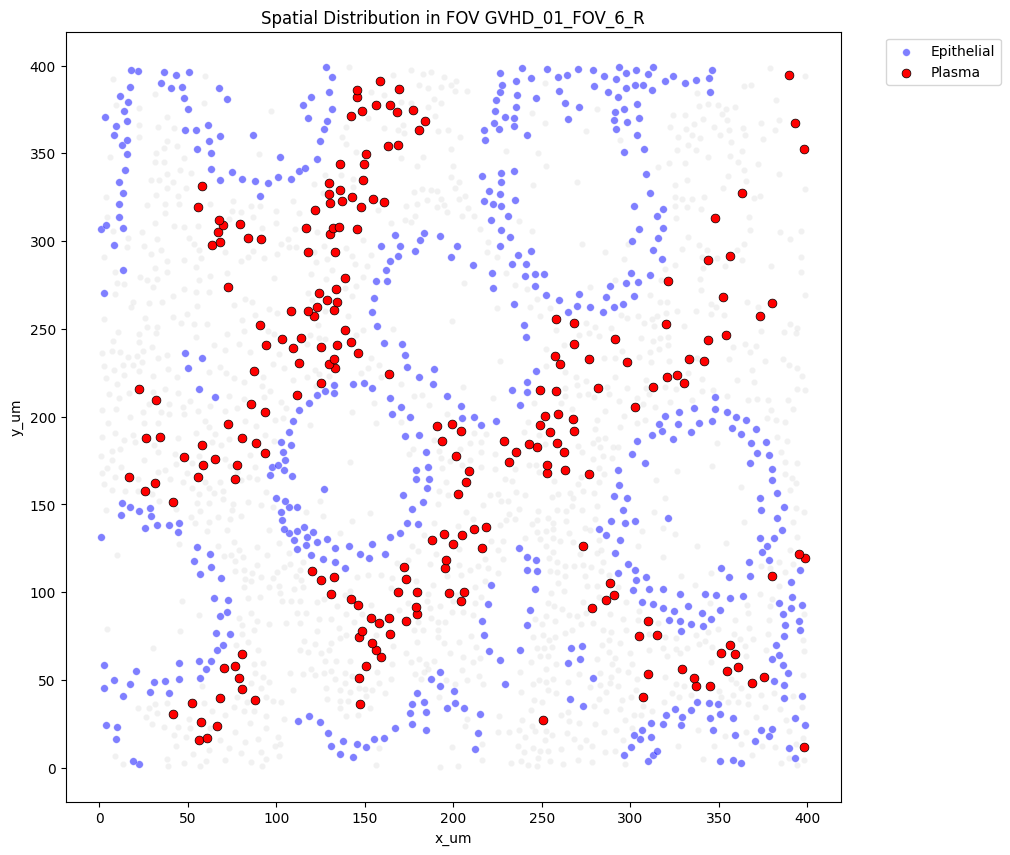

In [6]:
evaluate_cohort("Colon - Severe", colon_severe_fovs, df_cells)


Evaluating Cohort: Duodenum - Control

FOV: Control_01_FOV_1 | Transactions: 2618
  [Binary]   Sup: 0.0252 | Conf: 0.6286 | Lift: 1.3346 | PASS: True
  [Weighted] Sup: 0.0243 | Conf: 0.6067 | Lift: 1.3397 | PASS: True

FOV: Control_01_FOV_2 | Transactions: 2354
  [Binary]   Sup: 0.1109 | Conf: 0.8031 | Lift: 1.0497 | PASS: False
  [Weighted] Sup: 0.1067 | Conf: 0.7729 | Lift: 1.0373 | PASS: False

FOV: Control_01_FOV_3 | Transactions: 2157
  [Binary]   Sup: 0.0732 | Conf: 0.8634 | Lift: 1.1742 | PASS: False
  [Weighted] Sup: 0.0720 | Conf: 0.8490 | Lift: 1.1664 | PASS: False

FOV: Control_01_FOV_4 | Transactions: 2140
  [Binary]   Sup: 0.0780 | Conf: 0.8743 | Lift: 0.9393 | PASS: False
  [Weighted] Sup: 0.0766 | Conf: 0.8586 | Lift: 0.9313 | PASS: False

FOV: Control_02_FOV_1 | Transactions: 2305
  [Binary]   Sup: 0.0469 | Conf: 0.5510 | Lift: 0.7583 | PASS: False
  [Weighted] Sup: 0.0448 | Conf: 0.5268 | Lift: 0.7390 | PASS: False

FOV: Control_02_FOV_2 | Transactions: 2048
  [Binary]

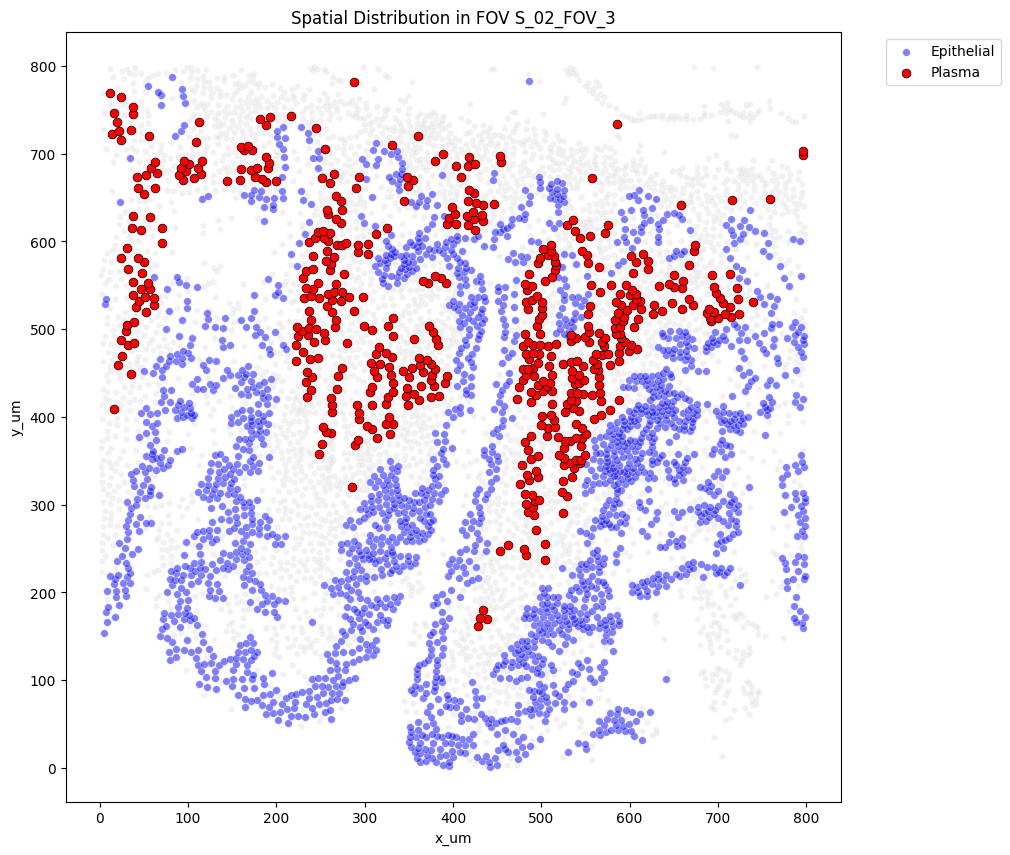

In [7]:
evaluate_cohort("Duodenum - Control", duodenum_control_fovs, df_cells)


Evaluating Cohort: Duodenum - Mild

FOV: GVHD_03_FOV_1_R | Transactions: 2879
  [Binary]   Sup: 0.0139 | Conf: 0.6061 | Lift: 0.9619 | PASS: False
  [Weighted] Sup: 0.0132 | Conf: 0.5761 | Lift: 0.9352 | PASS: False

FOV: GVHD_03_FOV_2 | Transactions: 2524
  [Binary]   Sup: 0.0079 | Conf: 0.6667 | Lift: 1.1377 | PASS: False
  [Weighted] Sup: 0.0075 | Conf: 0.6351 | Lift: 1.1062 | PASS: False

FOV: GVHD_03_FOV_3_R | Transactions: 2615
  [Binary]   Sup: 0.0046 | Conf: 0.8571 | Lift: 1.1453 | PASS: False
  [Weighted] Sup: 0.0043 | Conf: 0.8069 | Lift: 1.1074 | PASS: False

FOV: GVHD_03_FOV_4 | Transactions: 2443
  [Binary]   Sup: 0.0033 | Conf: 0.6667 | Lift: 0.8910 | PASS: False
  [Weighted] Sup: 0.0033 | Conf: 0.6667 | Lift: 0.9074 | PASS: False

FOV: GVHD_04_FOV_1 | Transactions: 2177
  [Binary]   Sup: 0.0078 | Conf: 0.9444 | Lift: 1.5096 | PASS: False
  [Weighted] Sup: 0.0077 | Conf: 0.9279 | Lift: 1.4990 | PASS: False

FOV: GVHD_04_FOV_2 | Transactions: 2031
  [Binary]   Sup: 0.0054 

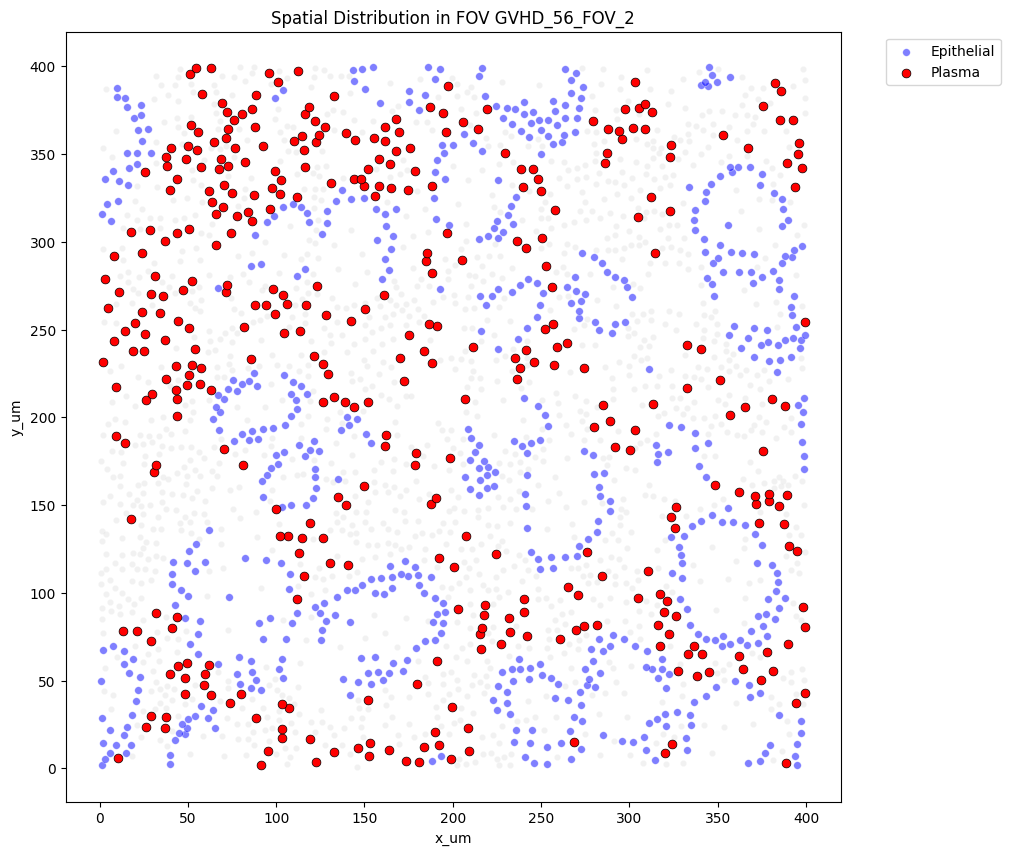

In [8]:
evaluate_cohort("Duodenum - Mild", duodenum_mild_fovs, df_cells)


Evaluating Cohort: Duodenum - Severe

FOV: GVHD_02_FOV_1_R | Transactions: 1977
  [Binary]   Sup: 0.0172 | Conf: 0.3238 | Lift: 0.5994 | PASS: False
  [Weighted] Sup: 0.0169 | Conf: 0.3173 | Lift: 0.6204 | PASS: False

FOV: GVHD_02_FOV_2_R | Transactions: 1722
  [Binary]   Sup: 0.0145 | Conf: 0.3247 | Lift: 0.8115 | PASS: False
  [Weighted] Sup: 0.0138 | Conf: 0.3089 | Lift: 0.8372 | PASS: False

FOV: GVHD_06_FOV_1 | Transactions: 2174
  [Binary]   Sup: 0.0014 | Conf: 0.0361 | Lift: 0.1644 | PASS: False
  [Weighted] Sup: 0.0009 | Conf: 0.0248 | Lift: 0.1333 | PASS: False

FOV: GVHD_06_FOV_2 | Transactions: 2265
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_06_FOV_3 | Transactions: 1998
  [Binary]   Sup: 0.0030 | Conf: 0.0811 | Lift: 0.4402 | PASS: False
  [Weighted] Sup: 0.0025 | Conf: 0.0664 | Lift: 0.4041 | PASS: False

FOV: GVHD_06_FOV_4 | Transactions: 2040
  [Binary]   Sup: 0.002

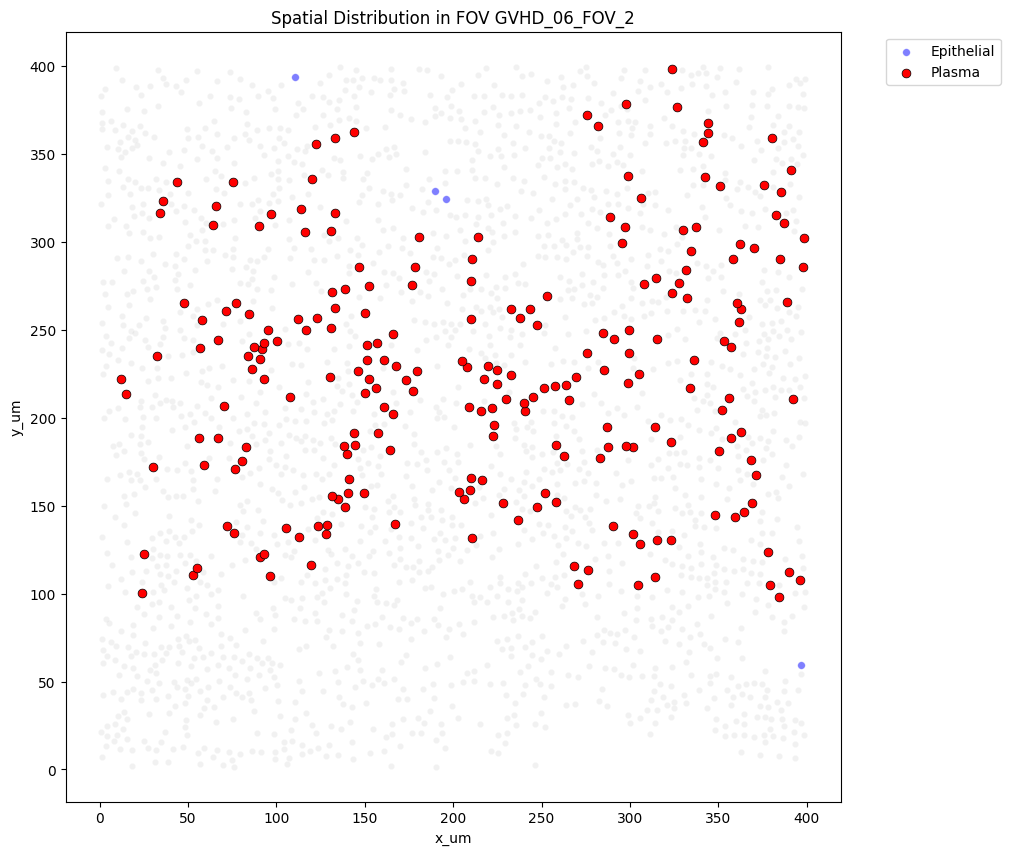

In [9]:
evaluate_cohort("Duodenum - Severe", duodenum_severe_fovs, df_cells)


## Step 4: Run Evaluation on Mild Cohort (Stage 1)

## Step 5: Run Evaluation on Severe Cohort (Stage 3)